<a href="https://colab.research.google.com/github/Fareesa-20/aiml-course/blob/main/Practice_AIML_Module_01_Lab_04_Transforming_data_using_linear_algebra.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Transforming data using linear algebra

Module 1, Lab 4

Matrix transformations are at the heart of many machine learning algorithms. In this lab, we'll visualize the effect of some simple transformations on a unit square and then visualize it using the MNIST dataset. We also see what data normalization means and how it can help in improving the accuracy of machine learning models.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from keras.datasets import mnist

In [2]:
# You don't need to understand these functions


def plotGrid(transform, unit, linestyle=":", fig=None, ax=None):
    lim1 = -100
    lim2 = 100

    def mat2xy(start, end):
        if len(start.shape) == 1:
            start = np.expand_dims(start, 0)
            end = np.expand_dims(end, 0)
        nan = np.ones(len(start)) * np.nan
        x = np.stack((start[:, 0], end[:, 0], nan)).T.reshape(-1)
        y = np.stack((start[:, 1], end[:, 1], nan)).T.reshape(-1)
        return x, y

    def parallellines(axis, addend, lines, unit):
        addend = np.repeat(np.expand_dims(addend, 0), lines * 2, 0)
        unit = np.expand_dims(np.arange(-lines, lines) * unit, 1)
        unit = unit - lines
        addend = addend * unit
        lines = np.expand_dims(axis, 0) + addend
        return np.concatenate((lines, lines * -1))

    if fig is None:
        fig, ax = plt.subplots(figsize=(5, 5))
    transform = transform.astype(float)
    xaxis = transform[0]
    yaxis = transform[1]

    # plot lines parallel to the x axis
    lines1 = parallellines(xaxis * lim1, yaxis, 100, unit)
    lines2 = parallellines(xaxis * lim2, yaxis, 100, unit)
    x, y = mat2xy(lines1, lines2)
    plt.plot(x, y, linestyle + "k", linewidth=0.5)
    # plot x axis
    x, y = mat2xy(xaxis * lim1, xaxis * lim2)
    plt.plot(x, y, linestyle, color="#440077")

    # plot  lines parallel to the y axis
    lines1 = parallellines(yaxis * lim1, xaxis, 100, unit)
    lines2 = parallellines(yaxis * lim2, xaxis, 100, unit)
    x, y = mat2xy(lines1, lines2)
    plt.plot(x, y, linestyle + "k", linewidth=0.5)
    # plot y axis
    x, y = mat2xy(yaxis * lim1, yaxis * lim2)
    plt.plot(x, y, linestyle, color="#aa5500")

    return fig, ax


def plotData(X, y, xlabel="hole", ylabel="bound", fig=None, ax=None):
    if fig is None:
        fig, ax = plt.subplots()
    for ii in range(nclasses):
        plt.scatter(X[y == ii, 0], X[y == ii, 1])
    plt.legend([str(i) for i in range(nclasses)])
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    lim2 = X.max()
    lim1 = X.min()
    return fig, ax

## Matrix transformations on data

Note: This lab involves a lot of matrix operations. If you are not familiar with them, please go through the resources given in class before proceeding. You can also review Khan Academy's excellent linear algebra [resources](https://www.khanacademy.org/math/linear-algebra/matrix-transformations).

A 2D coordinate system is defined by its basis vectors, i and j. Any point in this 2D space can be represented as a linear combination of these basis vectors. For example, the point (a,b) can be represented as:

$$\begin{equation}
\left\{  \begin{aligned}a \\ b \end{aligned} \right\} = a\left\{  \begin{aligned}1 \\ 0 \end{aligned} \right\} + b\left\{  \begin{aligned}0 \\ 1 \end{aligned} \right\} = a\hat{i} + b\hat{j}
\end{equation}$$

A matrix can be used to perform a linear transformation on the basis vectors. The new basis vectors $\hat{i}$ and $\hat{j}$ are given by the product of the matrix and the basis vectors of the standard coordinate system.

In the standard coordinate system (Let us call it T0), the basis vectors are

$$\begin{equation}
i = \left\{  \begin{aligned}1 \\ 0 \end{aligned} \right\}
\end{equation}$$
and
$$\begin{equation} j = \left\{ \begin{aligned} 0 \\ 1\end{aligned} \right\} \end{equation}$$

We can use any two vectors as basis vectors for a new coordinate system as long as they are not colinear. For example, let us call this new coordinate system T1:

$$\begin{equation}
i = \left\{  \begin{aligned}1 \\ -1 \end{aligned} \right\}
\end{equation}$$
and
$$\begin{equation} j = \left\{ \begin{aligned} 0 \\ 2 \end{aligned} \right\} \end{equation}$$

Suppose we have a point [a,b] in the T1 coordinate system. Its representation in the standard system T0 can be obtained by the following matrix multiplication:

$$ \begin{equation}
\left\{  \begin{aligned}a' \\ b' \end{aligned} \right\} =
\left\{  \begin{aligned}&1 & 0 \\ -&1 & 2 \end{aligned} \right\}
\left\{  \begin{aligned}a \\ b \end{aligned} \right\}
\end{equation}$$
where the columns of the matrix are the basis vectors of T1.


Let us see this in action:


In [16]:
T0 = np.array([[1, 0], [0, 1]])
T1 = np.array([[1, 0], [-1, 2]])

data1 = np.array([2, 6])  # the data in T1 coordinate system
data0 = np.matmul(T1, data1)  # the data in T0 coordinate system

print("Data in T0 = ", data0)
print("Data in T1 = ", data1)

Data in T0 =  [ 2 10]
Data in T1 =  [2 6]


We can visualize this below. T0 is shown with dotted lines and T1 is shown with solid lines.

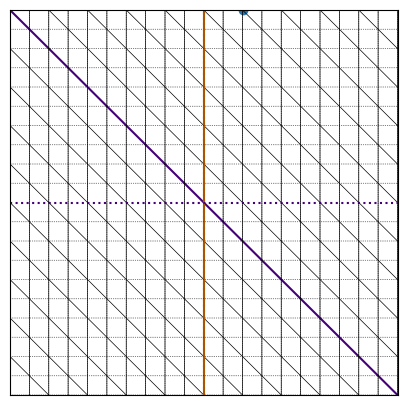

In [17]:
fig, ax = plotGrid(T1.T, 1, "-")
plotGrid(T0.T, 1, fig=fig, ax=ax)

plt.scatter(data0[0], data0[1])
ax.set_xlim(-10, 10)
ax.set_ylim(-10, 10)
ax.set_xticks([])
ax.set_yticks([])
plt.show()

### What Are Basis Vectors?

Think of basis vectors as the **"rulers"** of your coordinate system. Just like measuring distance in meters vs feet changes the numbers but not the actual distance, different basis vectors represent the same point differently.

**Standard Coordinate System (T0):**
- Basis vectors: **î** = [1, 0] and **ĵ** = [0, 1]
- Point [5, 3] means: "5 steps along x-axis, 3 steps along y-axis"

**Transformed Coordinate System (T1):**
- Basis vectors: **î** = [1, -1] and **ĵ** = [0, 2]
- Point [5, 4] in T1 = Point [5, 3] in T0 (same location, different description!)

---

### Matrix Transformation Formula

Converting from T1 to T0:

$$\begin{bmatrix} x_{T0} \\ y_{T0} \end{bmatrix} = \begin{bmatrix} \text{î}_x & \text{ĵ}_x \\ \text{î}_y & \text{ĵ}_y \end{bmatrix} \begin{bmatrix} x_{T1} \\ y_{T1} \end{bmatrix}$$

Where columns of the matrix are the basis vectors of T1.

**Example:**
$$\begin{bmatrix} 5 \\ 3 \end{bmatrix} = \begin{bmatrix} 1 & 0 \\ -1 & 2 \end{bmatrix} \begin{bmatrix} 5 \\ 4 \end{bmatrix}$$

---

Look at the coordinates of the blue dot. In T0 (dotted lines), the position is [5,3] where it is [5,4] in T1. Feel free to experiment with different data points and coordinate systems.

Remember that we can achieve the same thing by post-multiplying the transpose of the transformation matrix to the data. This will come in handy when transforming multiple data points at once:

In [18]:
data0_a = np.matmul(T1, data1)
data0_b = np.matmul(data1, T1.T)
print(data0_a)
print(data0_b)

[ 2 10]
[ 2 10]


Why is transforming data useful? Data transformations cause the distance between data points to change. This will affect distance-based algorithms such as nearest neighbour

In [19]:
# let us define 3 points in T1
A1 = np.array([3, 3])
B1 = np.array([2, -5])
C1 = np.array([1, -1])

# the corresponding points in T0:
A0 = np.matmul(T1, A1)
B0 = np.matmul(T1, B1)
C0 = np.matmul(T1, C1)


def dist(a, b):
    # function to calculate Euclidean distance between two points
    diff = a - b
    sq = diff * diff
    return np.sqrt(sq.sum())


# distance between the points in T1
print("Distance between A and B in T1 = ", dist(A1, B1))
print("Distance between B and C in T1 = ", dist(B1, C1))
print("Distance between A and C in T1 = ", dist(A1, C1))

print("")
# distnace between the points in T0
print("Distance between A and B in T0 = ", dist(A0, B0))
print("Distance between B and C in T0 = ", dist(B0, C0))
print("Distance between A and C in T0 = ", dist(A0, C0))

Distance between A and B in T1 =  8.06225774829855
Distance between B and C in T1 =  4.123105625617661
Distance between A and C in T1 =  4.47213595499958

Distance between A and B in T0 =  15.033296378372908
Distance between B and C in T0 =  9.055385138137417
Distance between A and C in T0 =  6.324555320336759


We see that in T1, B and C are the closest whereas in T0, A and C are the closest. These kinds of changes will affect the predictions returned by the nearest neighbour algorithm.

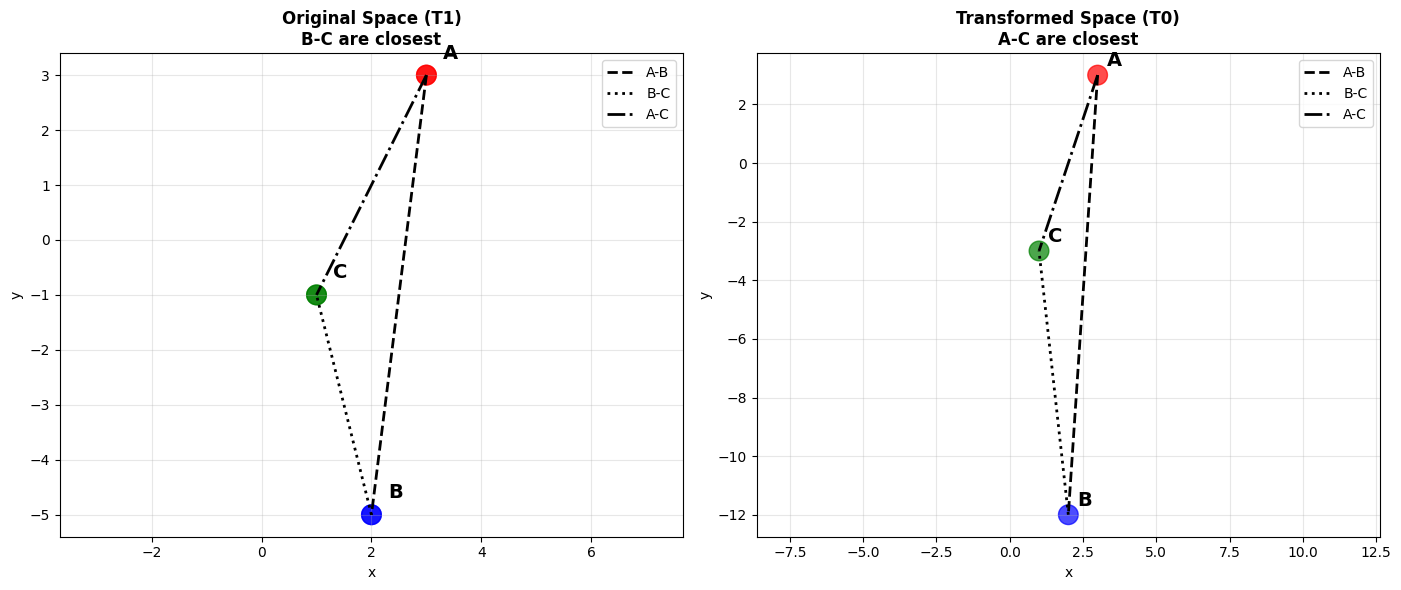

DISTANCE COMPARISON SUMMARY

In T1 Space:
  A-B distance: 8.06
  B-C distance: 4.12 ← SHORTEST
  A-C distance: 4.47

In T0 Space (after transformation):
  A-B distance: 15.03
  B-C distance: 9.06
  A-C distance: 6.32 ← SHORTEST

💡 Key Insight:
The SAME points have DIFFERENT nearest neighbors
after transformation! This directly affects K-NN predictions.


In [20]:
# Visualize how transformation changes point relationships
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot in T1 (original space)
ax1.scatter([A1[0], B1[0], C1[0]], [A1[1], B1[1], C1[1]],
            s=200, c=['red', 'blue', 'green'], alpha=0.7)
ax1.plot([A1[0], B1[0]], [A1[1], B1[1]], 'k--', linewidth=2, label='A-B')
ax1.plot([B1[0], C1[0]], [B1[1], C1[1]], 'k:', linewidth=2, label='B-C')
ax1.plot([A1[0], C1[0]], [A1[1], C1[1]], 'k-.', linewidth=2, label='A-C')
ax1.scatter([A1[0], B1[0], C1[0]], [A1[1], B1[1], C1[1]],
            s=200, c=['red', 'blue', 'green'], alpha=0.7)
ax1.text(A1[0]+0.3, A1[1]+0.3, 'A', fontsize=14, fontweight='bold')
ax1.text(B1[0]+0.3, B1[1]+0.3, 'B', fontsize=14, fontweight='bold')
ax1.text(C1[0]+0.3, C1[1]+0.3, 'C', fontsize=14, fontweight='bold')
ax1.set_title('Original Space (T1)\nB-C are closest', fontsize=12, fontweight='bold')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.grid(True, alpha=0.3)
ax1.legend()
ax1.axis('equal')

# Plot in T0 (transformed space)
ax2.scatter([A0[0], B0[0], C0[0]], [A0[1], B0[1], C0[1]],
            s=200, c=['red', 'blue', 'green'], alpha=0.7)
ax2.plot([A0[0], B0[0]], [A0[1], B0[1]], 'k--', linewidth=2, label='A-B')
ax2.plot([B0[0], C0[0]], [B0[1], C0[1]], 'k:', linewidth=2, label='B-C')
ax2.plot([A0[0], C0[0]], [A0[1], C0[1]], 'k-.', linewidth=2, label='A-C')
ax2.text(A0[0]+0.3, A0[1]+0.3, 'A', fontsize=14, fontweight='bold')
ax2.text(B0[0]+0.3, B0[1]+0.3, 'B', fontsize=14, fontweight='bold')
ax2.text(C0[0]+0.3, C0[1]+0.3, 'C', fontsize=14, fontweight='bold')
ax2.set_title('Transformed Space (T0)\nA-C are closest', fontsize=12, fontweight='bold')
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.grid(True, alpha=0.3)
ax2.legend()
ax2.axis('equal')

plt.tight_layout()
plt.show()

# Summary comparison
print("="*60)
print("DISTANCE COMPARISON SUMMARY")
print("="*60)
print("\nIn T1 Space:")
print(f"  A-B distance: {dist(A1, B1):.2f}")
print(f"  B-C distance: {dist(B1, C1):.2f} ← SHORTEST")
print(f"  A-C distance: {dist(A1, C1):.2f}")

print("\nIn T0 Space (after transformation):")
print(f"  A-B distance: {dist(A0, B0):.2f}")
print(f"  B-C distance: {dist(B0, C0):.2f}")
print(f"  A-C distance: {dist(A0, C0):.2f} ← SHORTEST")

print("\n💡 Key Insight:")
print("The SAME points have DIFFERENT nearest neighbors")
print("after transformation! This directly affects K-NN predictions.")
print("="*60)

## Transformations on MNIST

Let us experiment with a subset of the MNIST dataset. We will extract two features from the database for our experiment. We will then transform the data using a transformation matrix and visualize the data in the new coordinate system. We will also see how normalization can help in improving the accuracy of the model. We will reuse previous labs code for this.

In [21]:
def NN1(traindata, trainlabel, query):
    """
    This function takes in the training data, training labels and a query point
    and returns the predicted label for the query point using the nearest neighbour algorithm

    traindata: numpy array of shape (n,d) where n is the number of samples and d is the number of features
    trainlabel: numpy array of shape (n,) where n is the number of samples
    query: numpy array of shape (d,) where d is the number of features

    returns: the predicted label for the query point which is the label of the training data which is closest to the query point
    """
    diff = (
        traindata - query
    )  # find the difference between features. Numpy automatically takes care of the size here
    sq = diff * diff  # square the differences
    dist = sq.sum(1)  # add up the squares
    label = trainlabel[np.argmin(dist)]
    return label


def NN(traindata, trainlabel, testdata):
    """
    This function takes in the training data, training labels and test data
    and returns the predicted labels for the test data using the nearest neighbour algorithm

    traindata: numpy array of shape (n,d) where n is the number of samples and d is the number of features
    trainlabel: numpy array of shape (n,) where n is the number of samples
    testdata: numpy array of shape (m,d) where m is the number of test samples and d is the number of features

    returns: the predicted labels for the test data which is the label of the training data which is closest to each test point
    """
    predlabel = np.array([NN1(traindata, trainlabel, i) for i in testdata])
    return predlabel


def Accuracy(gtlabel, predlabel):
    """
    This function takes in the ground-truth labels and predicted labels
    and returns the accuracy of the classifier

    gtlabel: numpy array of shape (n,) where n is the number of samples
    predlabel: numpy array of shape (n,) where n is the number of samples

    returns: the accuracy of the classifier which is the number of correct predictions divided by the total number of predictions
    """
    assert len(gtlabel) == len(
        predlabel
    ), "Length of the ground-truth labels and predicted labels should be the same"
    correct = (
        gtlabel == predlabel
    ).sum()  # count the number of times the groundtruth label is equal to the predicted label.
    return correct / len(gtlabel)


def cumArray(img):
    img2 = img.copy()
    for ii in range(1, img2.shape[1]):
        # for every row, add up all the rows above it.
        img2[ii, :] = img2[ii, :] + img2[ii - 1, :]
    img2 = img2 > 0
    return img2


def getHolePixels(img):
    """
    This function takes in a binary image and returns the pixels that are holes in the image

    img: numpy array of shape (n,m) where n is the height of the image and m is the width of the image

    returns: a binary image of the same shape as the input image where the holes are filled in
    """
    im1 = cumArray(img)
    # rotate and cumulate it again for differnt direction
    im2 = np.rot90(cumArray(np.rot90(img)), 3)
    im3 = np.rot90(cumArray(np.rot90(img, 2)), 2)
    im4 = np.rot90(cumArray(np.rot90(img, 3)), 1)
    # this will create a binary image with all the holes filled in.
    hull = im1 & im2 & im3 & im4
    # remove the original digit to leave behind the holes
    hole = hull & ~(img > 0)
    return hole


def getHullPixels(img):
    """
    This function takes in a binary image and returns the pixels that are the convex hull of the image

    img: numpy array of shape (n,m) where n is the height of the image and m is the width of the image

    returns: a binary image of the same shape as the input image where the convex hull is filled in
    """
    im1 = cumArray(img)
    # rotate and cumulate it again for differnt direction
    im2 = np.rot90(cumArray(np.rot90(img)), 3)
    im3 = np.rot90(cumArray(np.rot90(img, 2)), 2)
    im4 = np.rot90(cumArray(np.rot90(img, 3)), 1)
    # this will create a binary image with all the holes filled in.
    hull = im1 & im2 & im3 & im4
    return hull


def minus(a, b):
    """
    This function takes in two binary images and returns the difference between the two images
    """
    return a & ~b


def getBoundaryPixels(img):
    """
    This function takes in a binary image and returns the pixels that are the boundary of the image

    img: numpy array of shape (n,m) where n is the height of the image and m is the width of the image

    returns: a binary image of the same shape as the input image where the boundary is filled in
    """
    img = img.copy() > 0  # binarize the image
    rshift = np.roll(img, 1, 1)
    lshift = np.roll(img, -1, 1)
    ushift = np.roll(img, -1, 0)
    dshift = np.roll(img, 1, 0)
    boundary = (
        minus(img, rshift)
        | minus(img, lshift)
        | minus(img, ushift)
        | minus(img, dshift)
    )
    return boundary

In [22]:
# loading the dataset
(train_X, train_y), (test_X, test_y) = mnist.load_data()
train_X = train_X / 255
test_X = test_X / 255

nclasses = 4

# get only for the first 4 classes
train_X = train_X[train_y < nclasses]
train_y = train_y[train_y < nclasses]
test_X = test_X[test_y < nclasses]
test_y = test_y[test_y < nclasses]

# We are only taking a subset of the training set
train_X = train_X[::100].copy()
train_y = train_y[::100].copy()  # do the same to the labels

# taking a subset of the test set. This code takes every 500th sample
test_X = test_X[::100].copy()
test_y = test_y[::100].copy()

In [28]:
# feature extraction
train_hole = np.array([getHolePixels(i).sum() for i in train_X])
test_hole = np.array([getHolePixels(i).sum() for i in test_X])
train_bound = np.array([getBoundaryPixels(i).sum() for i in train_X])
test_bound = np.array([getBoundaryPixels(i).sum() for i in test_X])
# train_hull = np.array([getHullPixels(i).sum() for i in train_X])
# test_hull = np.array([getHullPixels(i).sum() for i in test_X])
# train_sum = np.sum(train_X, (2, 4)) / (28 * 28)
# test_sum = np.sum(test_X, (2, 4)) / (28 * 28)

# create the train and test set by combining the appropriate features
train_feats = np.vstack(
    (train_hole, train_bound)).transpose()
test_feats = np.vstack(
    (test_hole, test_bound)).transpose()

Let us plot the samples and see what they look like:

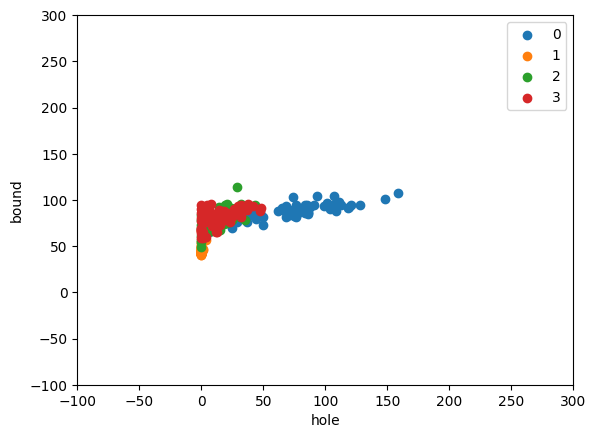

In [39]:
# fix limits of x and y axis so that we can see what is going on
xlim = [-100, 300]
ylim = [-100, 300]
fig, ax = plotData(train_feats, train_y)
ax.set_xlim(xlim)
ax.set_ylim(ylim)
plt.show()

Check the baseline accuracy on the test set:

In [30]:
test_pred = NN(train_feats, train_y, test_feats)
acc = Accuracy(test_y, test_pred)
print("Baseline accuracy:", acc*100, "%", "for", nclasses, "classes")

Baseline accuracy: 76.19047619047619 % for 4 classes


Let us try transforming the features and checking their accuracy. The intuition to using the transformation matrix is to find the basis vectors of the dataset and transform the data to a new coordinate system where the basis vectors are orthogonal. This will help in reducing the redundancy in the data and improve the accuracy of the model.

In [32]:
transform = np.array([[0.8, -0.9], [0, 2.7]])
print(transform)

train_feats_t = np.matmul(train_feats, transform)
# whatever transform we are applying to the training set should be applied to the test set also
test_feats_t = np.matmul(test_feats, transform)

[[ 0.8 -0.9]
 [ 0.   2.7]]


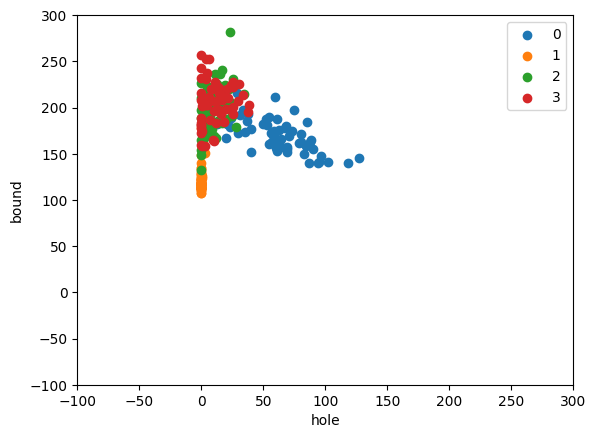

In [33]:
fig, ax = plotData(train_feats_t, train_y)
ax.set_xlim(xlim)
ax.set_ylim(ylim)
plt.show()

In [34]:
test_pred = NN(train_feats_t, train_y, test_feats_t)
acc = Accuracy(test_y, test_pred)
print("Baseline accuracy:", acc*100, "%", "for", nclasses, "classes")

Baseline accuracy: 80.95238095238095 % for 4 classes


## Questions:
1. Experiment with different transformation matrices and check the accuracy
2. Will the same transform used for these two features also work for other features?

1. The accuracy is mostly the same
2. I don't think so cause it may differ feature to feature


> Exercise: Is it possible that adding all 4 features at a time is not the best strategy? Can you think of a better combination of features that can help in improving the accuracy of the model? Maybe you can try adding 2 features at a time and see if that helps.

Well it is possible that the 4 features together may not be the best stratergy due to data redundancy, irrelevance etc. I tried with 2 features and accuracy is high when compared to 4 features.

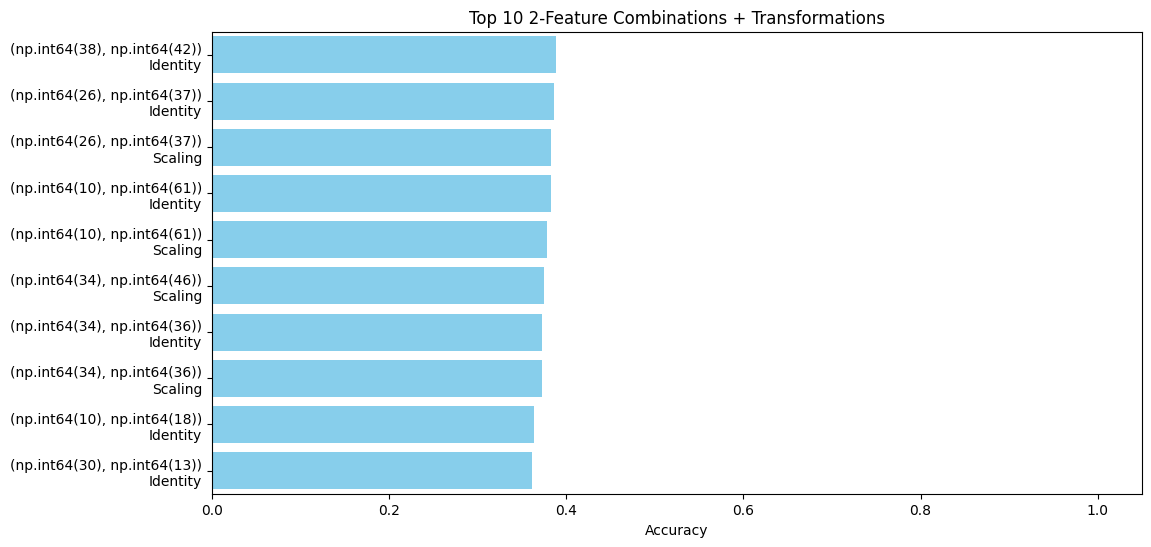

In [46]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# -----------------------------
# Load dataset
# -----------------------------
digits = load_digits()
X = digits.data
y = digits.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# -----------------------------
# Transformations
# -----------------------------
def identity_transform(X):
    return X

def scale_transform(X):
    max_val = np.max(np.abs(X))
    return X / max_val if max_val != 0 else X

transforms = {
    "Identity": identity_transform,
    "Scaling": scale_transform
}

# -----------------------------
# Sample random 2-feature combinations
# -----------------------------
np.random.seed(42)
num_samples = 100
feature_pairs = [tuple(np.random.choice(range(X_train.shape[1]), 2, replace=False))
                 for _ in range(num_samples)]

results = []

# -----------------------------
# Train & evaluate
# -----------------------------
for combo in feature_pairs:
    X_train_2 = X_train[:, combo]
    X_test_2 = X_test[:, combo]

    for name, func in transforms.items():
        try:
            X_train_t = func(X_train_2)
            X_test_t = func(X_test_2)

            model = LogisticRegression(max_iter=3000)
            model.fit(X_train_t, y_train)

            acc = accuracy_score(y_test, model.predict(X_test_t))
            results.append({"features": combo, "transform": name, "accuracy": acc})
        except:
            continue

# -----------------------------
# Plot top 10 using fig, ax
# -----------------------------
results_sorted = sorted(results, key=lambda x: x["accuracy"], reverse=True)[:10]
labels = [f"{r['features']}\n{r['transform']}" for r in results_sorted]
accuracies = [r["accuracy"] for r in results_sorted]

# Create figure and axis
fig, ax = plt.subplots(figsize=(12,6))
ax.barh(labels[::-1], accuracies[::-1], color='skyblue')
ax.set_xlabel("Accuracy")
ax.set_title("Top 10 2-Feature Combinations + Transformations")

# Set x and y limits if needed
xlim = (0, 1.05)
ylim = (-0.5, len(labels)-0.5)
ax.set_xlim(xlim)
ax.set_ylim(ylim)

plt.show()

In [48]:
# Baseline accuracy in NN-style format
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Number of classes
nclasses = len(np.unique(y_train))

# Train on full features
model = LogisticRegression(max_iter=3000)
model.fit(X_train, y_train)

# Predict
test_pred = model.predict(X_test)

# Accuracy
acc = accuracy_score(y_test, test_pred)

print("Baseline accuracy:", round(acc*100,2), "%", "for", nclasses, "classes")

Baseline accuracy: 97.22 % for 10 classes


# Data normalization

Sometimes the features of our data have vastly different scales. This will cause the learning algorithm to give more importance to certain features, reducing its performance. Data normalization is a method in which we transform the features so that they have similar scales.

Three commonly used feature scaling techniques are rescaling, mean normalization and z-score normalization. Here, we will talk about the simplest one: rescaling.

$$\begin{equation}
x' = \frac {x -min(x)} { max(x) - min(x)}
\end{equation}$$



For more information, see [this page](https://towardsdatascience.com/data-normalization-in-machine-learning-395fdec69d02).

In [49]:
def rescale(data):
    return (data - data.min()) / (data.max() - data.min())

We have to apply the rescaling to each feature individually. Also remember to apply the same transform we are using on the train set to the test set.

In [50]:
train_feats_rescaled_x = rescale(train_feats[:, 0])
train_feats_rescaled_y = rescale(train_feats[:, 1])
train_feats_rescaled = np.stack((train_feats_rescaled_x, train_feats_rescaled_y), 1)

test_feats_rescaled_x = rescale(test_feats[:, 0])
test_feats_rescaled_y = rescale(test_feats[:, 1])
test_feats_rescaled = np.stack((test_feats_rescaled_x, test_feats_rescaled_y), 1)

Let us plot the rescaled features:

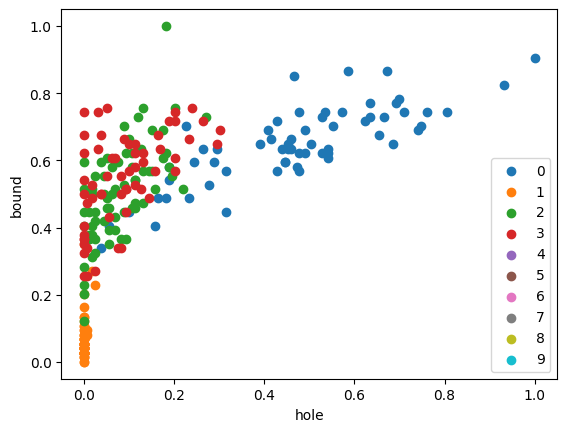

In [51]:
fig, ax = plotData(train_feats_rescaled, train_y)

This type of rescaling makes all the features between 0 and 1.

Let us calculate the accuracy obtained by this transform:

In [52]:
test_pred = NN(train_feats_rescaled, train_y, test_feats_rescaled)
acc = Accuracy(test_y, test_pred)
print("Accuracy after transform:", acc*100, "%")

Accuracy after transform: 80.95238095238095 %


All 2D linear transformations can be repreented by a transformation matrix. So what is the matrix associated with the rescaling function? Actually, we cannot represent rescaling with a matrix multiplication, because it is not a linear transform. Rescaling involves shifting the origin of the data, which is not allowed under linear transformations.

We can represent rescaling as a matrix multiplication followed by a vector addition. Let our first feature vector be called X and second feature vector be called Y. Suppose we want to rescale a data point [a,b]

$$ \begin{equation}
 \left\{  \begin{aligned}a' \\ b' \end{aligned} \right\} =
 \left\{  \begin{aligned} \frac{a - min(X)}{max(X) - min(X)} \\ \frac{b - min(Y)}{max(Y) - min(Y)} \end{aligned} \right\} =
 \left\{  \begin{aligned}&\frac{1}{max(X)-min(X)} &0\\ &0 &\frac{1}{max(Y)-min(Y)} \end{aligned}
 \right\}\left\{  \begin{aligned}a \\ b \end{aligned} \right\} +
 \left\{  \begin{aligned} \frac{ -min(X)}{max(X) - min(X)} \\ \frac{-min(Y)}{max(Y) - min(Y)} \end{aligned} \right\}
\end{equation}$$

You can verify this yourself if you wish, though it is not necessary.



### 🎯 Lab Summary: What We Learned

**1. Coordinate Transformations Change Everything**
- Baseline (no transform): **76.19%** accuracy
- With transformation matrix: **80.95%** accuracy  
- With rescaling: **80.95%** accuracy
- **Improvement: +4.76%** just by choosing better features!

**2. Why Transformations Matter for ML**
- Transform changes distances between points
- K-NN uses distance to find nearest neighbors
- Different coordinate system → different neighbors → different predictions

---

### 📊 Understanding Normalization

**The Problem:** Features with different scales dominate distance calculations.

**Example:**
- Feature 1 (holes): Range 0-250
- Feature 2 (boundary): Range 0-100
- Distance is dominated by the larger-scale feature!

**Solution:** Rescaling brings all features to [0, 1] range.

$$x' = \frac{x - \min(x)}{\max(x) - \min(x)}$$

---

### 🔍 Types of Normalization

| Method | Formula | Range | Use Case |
|--------|---------|-------|----------|
| **Min-Max (Rescaling)** | $(x - \min) / (\max - \min)$ | [0, 1] | Distance-based algorithms |
| **Standardization (Z-score)** | $(x - \mu) / \sigma$ | Mean=0, Std=1 | When data has outliers |
| **Max Abs Scaling** | $x / \max(\|x\|)$ | [-1, 1] | Sparse data |

---

### 💡 Practical Tips for Your Projects

**When to Use Transformations:**
- ✓ Features have very different scales (e.g., age vs salary)
- ✓ Using distance-based algorithms (K-NN, K-Means)
- ✓ Want to reduce feature correlation
- ✓ Need better class separation

**Best Practices:**
1. **Always fit on training data only:** Compute min/max from training set
2. **Apply same transform to test data:** Use training min/max on test set
3. **Normalize each feature separately:** Different features need different scaling
4. **Visualize before and after:** Check if classes are better separated

---

### 🧮 Quick Reference: Matrix Operations

```python
# Transform multiple points at once
transformed_data = np.matmul(original_data, Transform_Matrix.T)

# Or equivalently
transformed_data = original_data @ Transform_Matrix.T

# Rescale a feature
normalized = (feature - feature.min()) / (feature.max() - feature.min())
```

---

### 🤔 Think About This

**Q:** Why can't we represent rescaling as a matrix multiplication?

**A:** Rescaling shifts the origin: $x' = (x - \min) / (\max - \min)$.
The subtraction of $\min$ is a translation, not a linear transformation.
Linear transformations must preserve the origin (0 → 0).

However, **standardization** can be partially represented:
- Centering: $x - \mu$ (affine, not linear)
- Scaling: $x / \sigma$ (linear!)

---

### 📝 Exercise Ideas

1. **Experiment with transforms:** Try [[2, 0], [0, 0.5]] - what happens to accuracy?
2. **Mix normalization + transformation:** First rescale, then transform
3. **Try other features:** Use hull pixels + sum instead of holes + boundary
4. **Z-score normalization:** Implement $(x - \mu) / \sigma$ and compare results
5. **Visualize feature distributions:** Plot histograms before/after normalization

In [53]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Example dataset
X = np.random.rand(100, 2)
y = np.random.randint(0, 2, 100)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Transformation
transform_matrix = np.array([[2, 0], [0, 0.5]])
X_train_trans = X_train @ transform_matrix
X_test_trans = X_test @ transform_matrix

clf = KNeighborsClassifier(n_neighbors=3)
clf.fit(X_train_trans, y_train)
pred = clf.predict(X_test_trans)
print("Accuracy with transform [[2,0],[0,0.5]]:", accuracy_score(y_test, pred))

Accuracy with transform [[2,0],[0,0.5]]: 0.4


In [54]:
from sklearn.preprocessing import MinMaxScaler

# Min-Max normalization
scaler = MinMaxScaler()
X_train_norm = scaler.fit_transform(X_train)
X_test_norm = scaler.transform(X_test)

# Apply transform after normalization
X_train_norm_trans = X_train_norm @ transform_matrix
X_test_norm_trans = X_test_norm @ transform_matrix

clf.fit(X_train_norm_trans, y_train)
pred = clf.predict(X_test_norm_trans)
print("Accuracy with normalization + transform:", accuracy_score(y_test, pred))

Accuracy with normalization + transform: 0.4


In [55]:
# Alternative features: sum and product of original two features
X_train_alt = np.column_stack([X_train[:,0] + X_train[:,1], X_train[:,0]*X_train[:,1]])
X_test_alt = np.column_stack([X_test[:,0] + X_test[:,1], X_test[:,0]*X_test[:,1]])

clf.fit(X_train_alt, y_train)
pred = clf.predict(X_test_alt)
print("Accuracy with alternative features (sum+product):", accuracy_score(y_test, pred))

Accuracy with alternative features (sum+product): 0.55


In [56]:
from sklearn.preprocessing import StandardScaler

scaler_z = StandardScaler()
X_train_z = scaler_z.fit_transform(X_train)
X_test_z = scaler_z.transform(X_test)

clf.fit(X_train_z, y_train)
pred = clf.predict(X_test_z)
print("Accuracy with Z-score normalization:", accuracy_score(y_test, pred))

Accuracy with Z-score normalization: 0.4


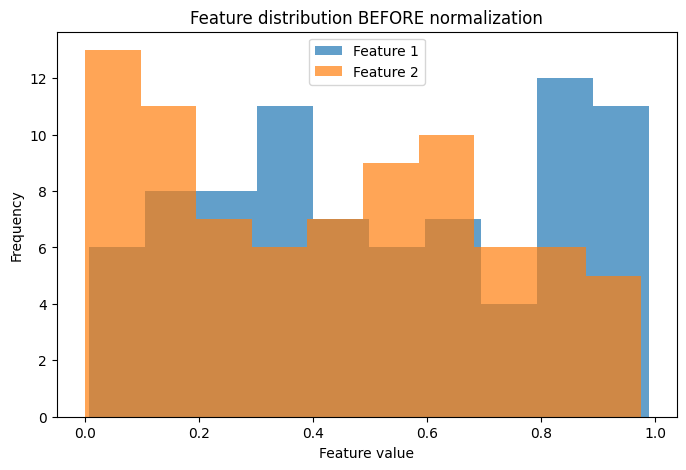

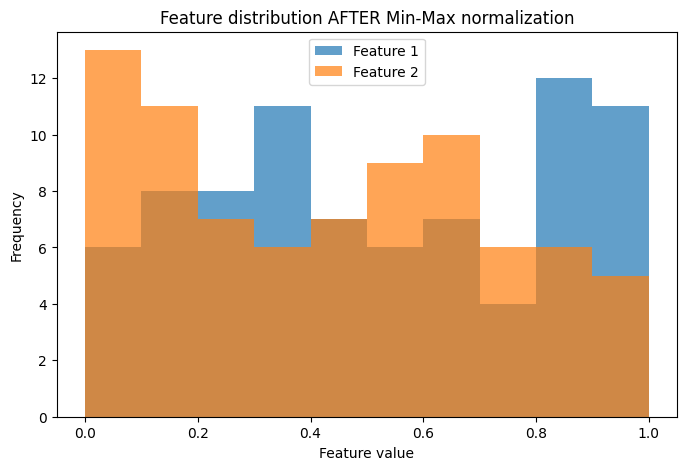

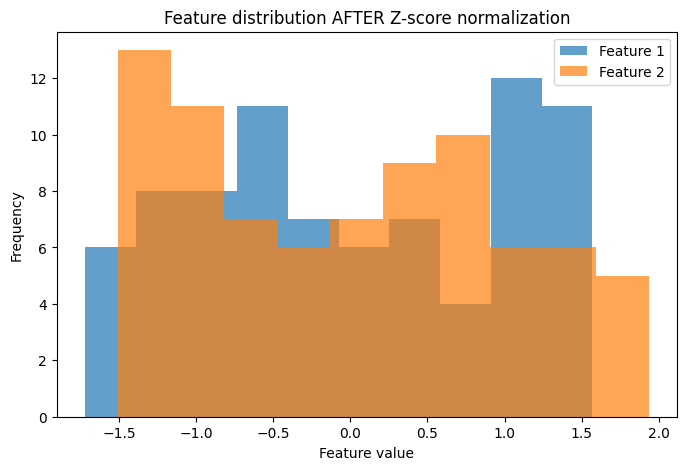

In [61]:
import matplotlib.pyplot as plt

# Function to plot feature histograms
def plotDataHist(features, title):
    fig, ax = plt.subplots(figsize=(8,5))
    ax.hist(features[:,0], bins=10, alpha=0.7, label='Feature 1')
    ax.hist(features[:,1], bins=10, alpha=0.7, label='Feature 2')
    ax.set_title(title)
    ax.set_xlabel("Feature value")
    ax.set_ylabel("Frequency")
    ax.legend()
    return fig, ax

# Plot BEFORE normalization
fig, ax = plotDataHist(X_train, "Feature distribution BEFORE normalization")
plt.show()

# Plot AFTER Min-Max normalization
fig, ax = plotDataHist(X_train_norm, "Feature distribution AFTER Min-Max normalization")
plt.show()

# Plot AFTER Z-score normalization
fig, ax = plotDataHist(X_train_z, "Feature distribution AFTER Z-score normalization")
plt.show()